[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9364 - loss: 0.2001 - val_accuracy: 0.9821 - val_loss: 0.0675
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9903 - loss: 0.0367 - val_accuracy: 0.9865 - val_loss: 0.0470
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9960 - loss: 0.0172 - val_accuracy: 0.9821 - val_loss: 0.0473
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9970 - loss: 0.0100 - val_accuracy: 0.9821 - val_loss: 0.0510
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9731 - val_loss: 0.0663
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9812 - loss: 0.0747
LSTM Accuracy: 0.9811659455299377


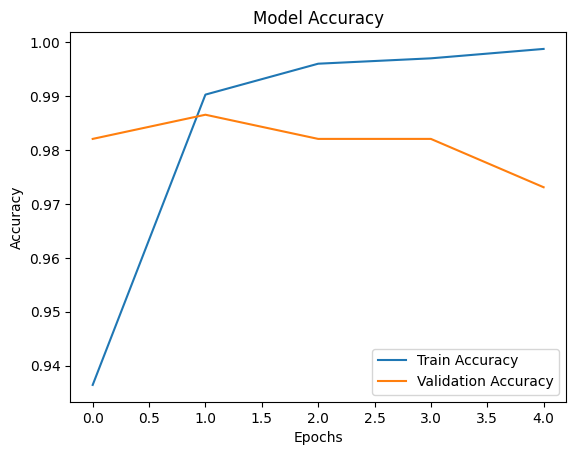

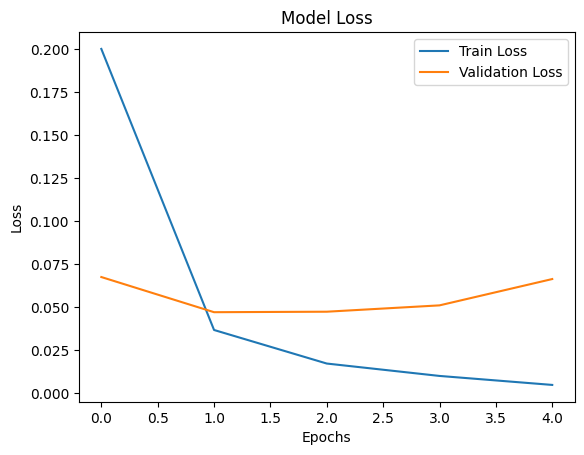

In [2]:
# Install TensorFlow
!pip install tensorflow

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')

# Load dataset
df = pd.read_csv("/content/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=100)
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model (store history)
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("LSTM Accuracy:", acc)

# -------------------------------
# Graphs
# -------------------------------

# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()